##Aerial Object Classification using CNN
Project Title

Aerial Object Classification & Detection

#Problem Statement

With the increasing use of drones in airspace, it has become important to distinguish between birds and drones in aerial imagery.

Misclassification may lead to:



*   aviation safety issuest item
*   false security alerts
*   incorrect wildlife monitoring

This project builds a deep learning-based image classification system capable of identifying whether an aerial image contains a bird or a drone.

#Import Libraries

In [1]:
# Import required libraries

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# Deep Learning Libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix

#Mount Google Drive

In [2]:
# Mount Google Drive to access dataset

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Define Dataset Paths

In [12]:
train_dir = "/content/drive/MyDrive/Aerial_Object_Project/classification_dataset/train"
val_dir = "/content/drive/MyDrive/Aerial_Object_Project/classification_dataset/valid"
test_dir = "/content/drive/MyDrive/Aerial_Object_Project/classification_dataset/test"

##Dataset Exploration

Before training the model, it is important to understand:

number of images in each class

dataset distribution

sample images

Check Dataset Distribution

In [4]:
# Count number of images in each category

print("Training Data")

print("Bird:", len(os.listdir(train_dir + "/bird")))
print("Drone:", len(os.listdir(train_dir + "/drone")))

print("\nValidation Data")

print("Bird:", len(os.listdir(val_dir + "/bird")))
print("Drone:", len(os.listdir(val_dir + "/drone")))

print("\nTest Data")

print("Bird:", len(os.listdir(test_dir + "/bird")))
print("Drone:", len(os.listdir(test_dir + "/drone")))

Training Data
Bird: 1414
Drone: 1248

Validation Data
Bird: 217
Drone: 225

Test Data
Bird: 121
Drone: 94


Visualize Sample Images

(np.float64(-0.5), np.float64(415.5), np.float64(415.5), np.float64(-0.5))

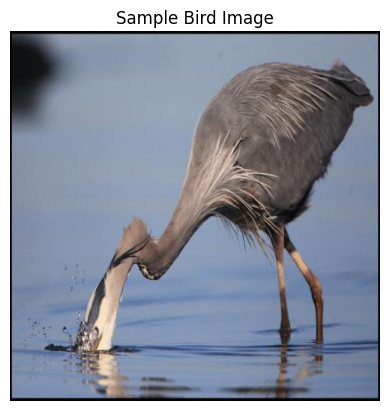

In [5]:
# Display a random bird image from the dataset

import random

bird_folder = train_dir + "/bird"

image_path = os.path.join(bird_folder, random.choice(os.listdir(bird_folder)))

image = cv2.imread(image_path)

# Convert image from BGR to RGB format
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Sample Bird Image")
plt.axis("off")

##Data Preprocessing and Augmentation

To improve model performance and reduce overfitting, we apply:

Image normalization

Rotation

Zoom

Horizontal flipping

Image Data Generators

In [6]:
# Data augmentation for training images

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True

)

# Only normalization for validation dataset

val_datagen = ImageDataGenerator(rescale=1./255)

#Load Dataset

In [7]:
# Load training dataset

train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode='binary'
)

# Load validation dataset

val_generator = val_datagen.flow_from_directory(

    val_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode='binary'
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


##Check Class labels

In [8]:
# Check how classes are encoded

print(train_generator.class_indices)

{'bird': 0, 'drone': 1}


#Build CNN Model

In [9]:
# Define CNN architecture

model = Sequential([

    # First Convolution Layer
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),

    MaxPooling2D(2,2),


    # Second Convolution Layer
    Conv2D(64,(3,3),activation='relu'),

    MaxPooling2D(2,2),


    # Third Convolution Layer
    Conv2D(128,(3,3),activation='relu'),

    MaxPooling2D(2,2),


    # Flatten feature maps
    Flatten(),


    # Fully Connected Layer
    Dense(128,activation='relu'),


    # Dropout to prevent overfitting
    Dropout(0.5),


    # Output layer (Binary classification)
    Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Compile Model

In [10]:
# Compile the CNN model

model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

#Train Model

In [11]:
# Train the model

history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=10
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 976s 12s/step - accuracy: 0.6063 - loss: 0.7261 - val_accuracy: 0.7285 - val_loss: 0.5541
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 347s 4s/step - accuracy: 0.7062 - loss: 0.5482 - val_accuracy: 0.7330 - val_loss: 0.5193
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 347s 4s/step - accuracy: 0.7562 - loss: 0.4979 - val_accuracy: 0.7692 - val_loss: 0.5311
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 347s 4s/step - accuracy: 0.7795 - loss: 0.4516 - val_accuracy: 0.7738 - val_loss: 0.4853
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 346s 4s/step - accuracy: 0.7923 - loss: 0.4369 - val_accuracy: 0.7805 - val_loss: 0.5230
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 349s 4s/step - accuracy: 0.8080 - loss: 0.4023 - val_accuracy: 0.7511 - val_loss: 0.5011
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 384s 4s/step - accuracy: 0.8287 - loss: 0.3709 - val_accuracy: 0.7805 - val_loss: 0.5514
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 344s 4s/step - accuracy: 0.8328 - loss: 0.3558 - val_accuracy: 0.7919 - 

Save Model

In [13]:
# Save trained model to Google Drive

save_path = "/content/drive/MyDrive/Aerial_Object_Project/models/cnn_model.h5"

model.save(save_path)

print("Model saved successfully at:", save_path)

Model saved successfully at: /content/drive/MyDrive/Aerial_Object_Project/models/cnn_model.h5


#Accuracy Graph

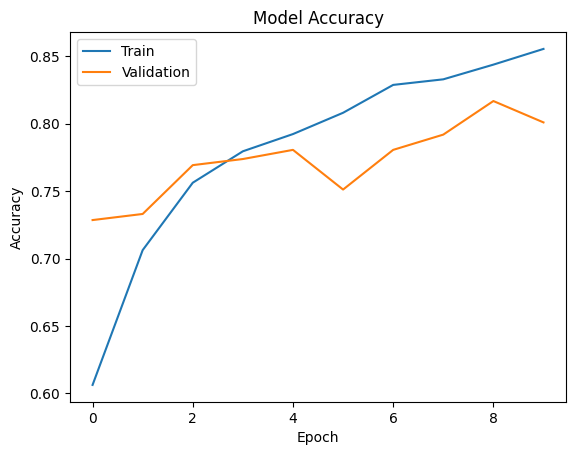

In [14]:
# Plot training and validation accuracy

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

#Loss Graph

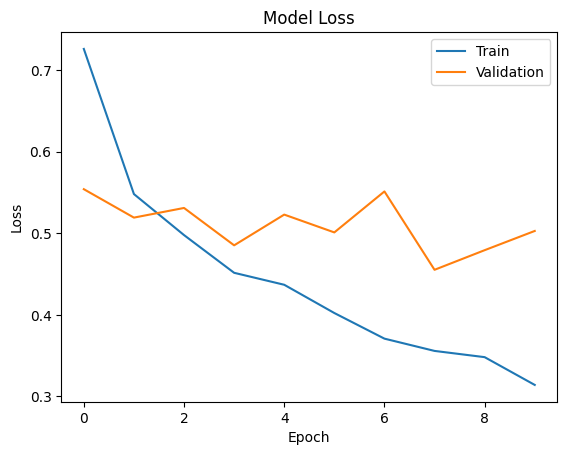

In [15]:
# Plot training and validation loss

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

#Test Data Evaluation

In [16]:
# Prepare test dataset

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(

    test_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode='binary',

    shuffle=False
)

Found 215 images belonging to 2 classes.


#Predictions

In [17]:
# Generate predictions

predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step


#Classification Report

In [18]:
# Display classification metrics

print(classification_report(test_generator.classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.92      0.84      0.88       121
           1       0.82      0.90      0.86        94

    accuracy                           0.87       215
   macro avg       0.87      0.87      0.87       215
weighted avg       0.87      0.87      0.87       215



##Confusion Matrix

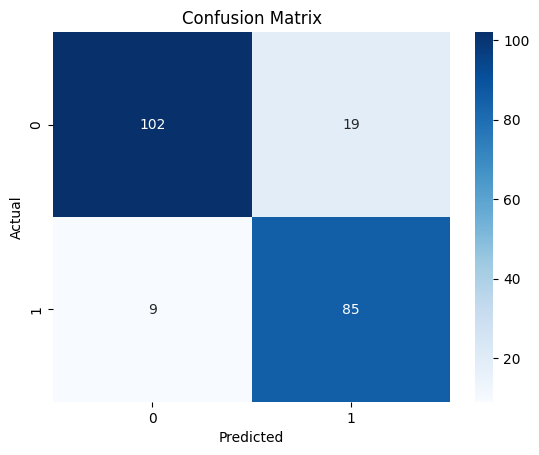

In [19]:
# Generate confusion matrix

cm = confusion_matrix(test_generator.classes, predicted_classes)

sns.heatmap(cm,annot=True,cmap="Blues",fmt="d")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

##Conclusion

In this notebook:




*   Aerial image dataset was explored

*   Images were preprocessed and augmented


*   A Custom CNN model was built and trained
*   Model performance was evaluated using multiple metrics









This CNN model will serve as the baseline model for comparison with Transfer Learning models.